In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score, fowlkes_mallows_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from umap import UMAP
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from pycocotools import mask as mask_utils

import re
import seaborn as sns
import pandas as pd
import cv2
import os
import json

import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
import torch.nn as nn
import torch
import sys

sys.path.append("../_Segmentation Model/")
sys.path.append("../")

import utils
from transforms import MaskResize, InstanceMaskCropper, PadToSizeTensor, MinMaxNormalize

In [2]:
image_root = '../data/Cerrado_trees.v1i.coco/_separated'
model_root = 'resnet34.pth'

class TreeCrownResNet34(nn.Module):
    """Fine-tuned ResNet34 for 512x512 tree crown masks"""

    def __init__(self, freeze_backbone=True, latent_dim=256, use_pretrained=True):
        super().__init__()
        
        # Load pretrained weights or random init
        weights = ResNet34_Weights.IMAGENET1K_V1 if use_pretrained else None
        self.backbone = models.resnet34(weights=weights)

        # Grab feature dimension before fc
        in_features = self.backbone.fc.in_features
        
        # Remove the final classifier head
        self.backbone.fc = nn.Identity()
        
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        # Projection head
        self.projection = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, in_features)
        )

        # Store preprocessing from weights (for transforms)
        self.preprocess = weights.transforms() if use_pretrained else None

    def encode(self, x):
        features = self.backbone(x)   # (B, 512)
        return self.projection(features)

    def forward(self, x):
        features = self.backbone(x)
        latent = self.projection(features)
        reconstructed = self.decoder(latent)
        return latent, reconstructed, features

In [3]:
model = TreeCrownResNet34(use_pretrained=False)
model.load_state_dict(torch.load("resnet34.pth"))

<All keys matched successfully>

    sizes = {'width':[], 'height':[]}
    
    for img in os.listdir(image_root):
        img_path = os.path.join(image_root, img)
        sizes['width'].append(cv2.imread(img_path).shape[0])
        sizes['height'].append(cv2.imread(img_path).shape[1])
    
    pd.DataFrame(sizes)

In [4]:
data_dict = {'image_path': [], 'label':[]}
for img in os.listdir(image_root):
    img_path = os.path.join(image_root, img)
    label = re.search(r'_(?:png|jpg)_(.+?)_\d+\.png$', img_path)
    data_dict['image_path'].append(img_path)
    if label:
        data_dict['label'].append(label.group(1))

In [5]:
data_df = pd.DataFrame(data_dict)
data_df.head()

,image_path,label
0,../data/Cerrado_trees.v1i.coco/_separated\DJI_...,Machaerium_opacum
1,../data/Cerrado_trees.v1i.coco/_separated\DJI_...,Eugenia_dysenterica
2,../data/Cerrado_trees.v1i.coco/_separated\DJI_...,Citrus
3,../data/Cerrado_trees.v1i.coco/_separated\DJI_...,Citrus
4,../data/Cerrado_trees.v1i.coco/_separated\DJI_...,Eugenia_dysenterica


In [10]:
image = cv2.imread(data_df['image_path'][0])

In [14]:
trans = transforms.Compose([
    transforms.ToTensor(),
    # PadToSizeTensor(3500, 3500),
    transforms.Resize(size=(500, 500)),
    MinMaxNormalize()
])

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
def predict(image):
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(dim=0).to(device)

        # --- Encode ---
        z = model.encode(image)  
        # latents.append(z.cpu())

        # --- Reconstruct ---
        out = model.decoder(z)
        # recons.append(out.cpu())

        return z.cpu(), out.cpu()

In [28]:
z, out = predict(trans(image))

In [32]:
out.shape

torch.Size([1, 512])

In [6]:
class PadToSizeTensor:
    """
    Pads a tensor image (C, H, W) to (target_height, target_width)
    using white padding. Image is centered.
    """
    def __init__(self, target_height, target_width, fill_value=1.0):
        """
        fill_value: 1.0 for normalized (0–1) tensors, 
                    255 for unnormalized (0–255) tensors
        """
        self.th = target_height
        self.tw = target_width
        self.fill_value = fill_value

    def __call__(self, img):
        """
        img: Tensor of shape (C, H, W)
        """
        if not isinstance(img, torch.Tensor):
            raise TypeError("PadToSizeTensor only supports torch.Tensor images.")

        if img.dim() != 3:
            raise ValueError("Expected tensor shape (C, H, W).")

        C, H, W = img.shape

        if H > self.th or W > self.tw:
            raise ValueError(
                f"Input image size {H}x{W} exceeds target size {self.th}x{self.tw}."
            )

        # Compute padding: (left, right, top, bottom)
        pad_left = (self.tw - W) // 2
        pad_right = self.tw - W - pad_left
        pad_top = (self.th - H) // 2
        pad_bottom = self.th - H - pad_top

        # pad = (pad_left, pad_right, pad_top, pad_bottom)
        padded = F.pad(
            img,
            (pad_left, pad_right, pad_top, pad_bottom),
            mode="constant",
            value=self.fill_value
        )

        return padded

In [7]:
class TDataset(Dataset):
    def __init__(self, data_dict, transforms=None):
        self.data_dict = data_dict
        self.transforms = transforms

    def __getitem__(self, idx):
        image = cv2.cvtColor(cv2.imread(self.data_dict['image_path'][idx]), cv2.COLOR_BGR2RGB)
        if self.transforms:
            image = self.transforms(image)
        return image

    def __len__(self):
        return len(self.data_dict['image_path'])

In [8]:
trans = transforms.Compose([
    transforms.ToTensor(),
    PadToSizeTensor(3500, 3500),
    transforms.Resize(size=(512, 512))
])

td = TDataset(data_dict, trans)

In [9]:
data_loader = DataLoader(td, batch_size=8, shuffle=False)

In [11]:
latent_batch_out = []
model.eval()
with torch.no_grad():
    for batch in tqdm(data_loader):
        latent_space, _, _ = model(batch)
        latent_batch_out.append(latent_space)

100%|██████████████████████████████████████████████████████████████████████████████████| 23/23 [00:33<00:00,  1.46s/it]


In [12]:
latent_batch_out = torch.concat(latent_batch_out, dim=0).cpu().numpy()

In [13]:
scaler = StandardScaler()
latent_scaled = scaler.fit_transform(latent_batch_out)

In [37]:
dbscan = DBSCAN(
    eps=30,        # maximum distance between samples in a neighborhood
    min_samples=30,  # minimum number of samples to form a dense region
    metric='euclidean'
)

dbscan.fit(latent_scaled)

labels = dbscan.labels_  # -1 means noise

In [38]:
umap_reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
latent_2d = umap_reducer.fit_transform(latent_scaled)

C:\Users\Brian\anaconda3\envs\dl_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


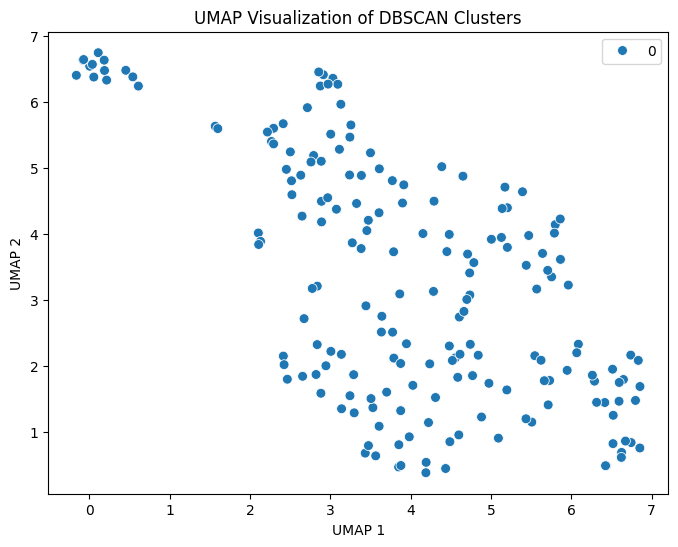

In [39]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=latent_2d[:,0],
    y=latent_2d[:,1],
    hue=labels,
    palette="tab10",
    legend="full",
    s=50
)
plt.title("UMAP Visualization of DBSCAN Clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [40]:
le = LabelEncoder()
y_true = le.fit_transform(data_df['label'].tolist())

In [41]:
y_pred = labels
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [42]:
ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
homogeneity = homogeneity_score(y_true, y_pred)
completeness = completeness_score(y_true, y_pred)
v_measure = v_measure_score(y_true, y_pred)
fmi = fowlkes_mallows_score(y_true, y_pred)

print(f"ARI: {ari:.3f}, NMI: {nmi:.3f}, V-measure: {v_measure:.3f}, FMI: {fmi:.3f}")

ARI: 0.000, NMI: 0.000, V-measure: 0.000, FMI: 0.316


In [62]:
model_recon = TreeCrownResNet34AE(freeze_backbone=False, use_pretrained=False)
model_recon.load_state_dict(torch.load("resnet34.pth"))

RuntimeError: Error(s) in loading state_dict for TreeCrownResNet34AE:
	Missing key(s) in state_dict: "decoder.2.weight", "decoder.2.bias", "decoder.6.weight", "decoder.6.bias", "decoder.8.weight", "decoder.8.bias", "decoder.10.weight", "decoder.10.bias". 
	Unexpected key(s) in state_dict: "decoder.1.weight", "decoder.1.bias". 
	size mismatch for decoder.0.weight: copying a param with shape torch.Size([512, 256]) from checkpoint, the shape in current model is torch.Size([16384, 256]).
	size mismatch for decoder.0.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([16384]).
	size mismatch for decoder.4.weight: copying a param with shape torch.Size([512, 512]) from checkpoint, the shape in current model is torch.Size([128, 64, 4, 4]).
	size mismatch for decoder.4.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([64]).

In [50]:
xx = next(iter(data_loader))

In [54]:
model.train()
yy = model(xx)

In [58]:
yy[0]

tensor([[-0.5931,  1.7555,  1.3605,  ...,  1.0298,  0.8030, -1.6360],
        [-0.3385, -0.2944, -0.2950,  ...,  1.6964,  1.2481, -1.3291],
        [ 2.4102, -1.8483, -2.3789,  ...,  0.2310, -0.1756,  1.1861],
        ...,
        [-2.1755,  1.2223,  1.5607,  ...,  0.5967,  0.8112, -2.5717],
        [-0.9308,  0.0965,  0.0840,  ...,  0.5727,  1.3892, -1.7642],
        [ 0.5673, -1.4180, -0.0423,  ...,  0.5323,  0.2773,  0.0399]],
       grad_fn=<AddmmBackward0>)